# Notebook 01 — Data Preprocessing
### WID2003 Cognitive Science | FSKTM, Universiti Malaya

---

## Overview

This notebook loads and cleans the two raw data files exported from **Tobii Pro Lab** after the eye-tracking session. The goal is to produce clean, well-structured files that all downstream notebooks can rely on.

**Inputs**
| File | Description |
|---|---|
| `data/raw/VisualTask_CogSci Metrics.tsv` | Pre-aggregated metrics per participant, per task, per AOI |
| `data/raw/VisualTask_CogSci Data export.tsv` | Raw gaze point stream (~3 GB, one row per sample, 130 participants) |

**Outputs**
| File | Description |
|---|---|
| `data/processed/metrics_clean.parquet` | Cleaned Metrics data |
| `data/processed/raw_gaze_clean.parquet` | Cleaned raw gaze data |

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish between the **Metrics TSV** (pre-aggregated per AOI) and the **Data export TSV** (raw gaze stream), and explain when each is used
2. Identify and handle **Tobii sentinel values** — placeholder strings Tobii writes when data is unavailable (e.g. no fixations in an AOI)
3. Compute a **valid gaze sample rate** per participant and explain what constitutes acceptable data quality for eye-tracking studies
4. Explain why participant ID normalisation is a critical pre-processing step before any data join
5. Explain why a multi-gigabyte raw export cannot always be loaded as a single `pd.read_csv()` call, and describe the column-pruning + chunked-read strategy used here to keep it within memory

---

## Background

### The Two Tobii Pro Lab Exports

**Metrics TSV** — Each row summarises one AOI during one trial for one participant. Key columns:

| Column | Cognitive meaning |
|---|---|
| `TOI` | Task name (e.g. `Crown`) |
| `AOI` | Region name (e.g. `C1`, `C2`) |
| `Total_duration_of_fixations` | Total ms the participant fixated on this AOI |
| `Number_of_fixations` | Count of fixation events in this AOI |
| `Time_to_first_fixation` | ms from trial start until first gaze entered this AOI |
| `Number_of_Visits` | How many times gaze entered and exited this AOI |
| `Average_pupil_diameter` | Mean pupil size while looking at this AOI |

**Data Export TSV** — One row per gaze sample (recorded at ~120 Hz). Contains raw gaze coordinates, eye movement classifications (`Fixation`, `Saccade`, `Unclassified`), pupil data, and binary `AOI hit` flags for every AOI at every moment.

### AOI Naming Convention
Each of the 13 task stimuli in this study has its own letter-prefixed AOI set (e.g. `C1`–`C10` for `Crown`, `H1`–`H10` for `Hat`), with exactly one AOI per task marked correct in `data/external/answer_key.json` — every other AOI for that stimulus is a distractor. `data/external/task_correct_aoi_map.json` records the full correct/distractor split per task.

### Memory-Safe Loading of the Data Export TSV
The real Data export TSV is ~3.1 GB across 4.5 million rows and 240+ columns — most of which (calibration details, viewport/window geometry, mouse coordinates, event markers) are unused by this pipeline. Loading it with a single unrestricted `pd.read_csv()` call can exhaust memory on a typical machine. Instead, this notebook:
1. Reads only the header first to discover the file's actual columns (AOI hit column names depend on which 13 tasks are in the file)
2. Restricts `usecols` to just the columns the pipeline actually consumes (participant/media identifiers, gaze/fixation coordinates, pupil, eye-movement type, and the `AOI hit [...]` columns)
3. Reads in fixed-size chunks (`chunksize=300_000`) so the CSV parser's peak memory stays bounded, then concatenates the (much narrower) chunks

### Data Quality Threshold
A participant's recording is flagged if fewer than **70%** of their gaze samples have valid coordinates. Causes of invalid samples include blinking, head movement, or the participant looking off-screen.

---

## Discussion Questions

1. Why must participant IDs be normalised (lowercased, stripped) before any analysis? What real-world problem does this prevent?
2. A participant has a 65% valid gaze rate. Should you include or exclude them from analysis? What factors would influence your decision?
3. The Metrics file contains many null values for some AOIs. Why might a participant have *zero* fixations on a particular AOI during a task?
4. What is the difference between a **fixation** and a **saccade**? Why does this distinction matter for studying visual search?
5. This notebook saves data as Parquet instead of CSV. What advantages does Parquet provide for large datasets?
6. This notebook drops raw per-eye pupil/eye-openness and calibration columns before loading, keeping only the filtered pupil signal used downstream. What is the trade-off between memory safety and preserving every raw column for future, not-yet-written analyses?

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/WID2003

!python -m pip install -q -r requirements.txt

# Important: notebook imports assume the working directory is notebooks/
%cd /content/drive/MyDrive/WID2003/notebooks

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from pathlib import Path

from src.config import (
    METRICS_TSV, DATAEXPORT_TSV,
    METRICS_CLEAN_PKL, RAWGAZE_CLEAN_PKL,
    MetricsCols, ExportCols, VALID_EYE_MOVEMENT_TYPES, TASKS
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)

In [2]:
# Create required directories if they don't exist
from src.config import (
    DATA_RAW, DATA_PROCESSED, DATA_EXTERNAL, 
    OUTPUTS_FIGURES, OUTPUTS_MODELS, OUTPUTS_REPORTS, 
    DATA_STIMULI
)

for path in [DATA_RAW, DATA_PROCESSED, DATA_EXTERNAL, 
             OUTPUTS_FIGURES, OUTPUTS_MODELS, OUTPUTS_REPORTS, 
             DATA_STIMULI]:
    path.mkdir(parents=True, exist_ok=True)
    print(f"Ensured directory exists: {path}")

Ensured directory exists: /home/wlsoo/WID2003/data/raw
Ensured directory exists: /home/wlsoo/WID2003/data/processed
Ensured directory exists: /home/wlsoo/WID2003/data/external
Ensured directory exists: /home/wlsoo/WID2003/outputs/figures
Ensured directory exists: /home/wlsoo/WID2003/outputs/models
Ensured directory exists: /home/wlsoo/WID2003/outputs/reports
Ensured directory exists: /home/wlsoo/WID2003/data/stimuli


## 1. Load Metrics TSV

In [3]:
metrics_raw = pd.read_csv(METRICS_TSV, sep='\t', low_memory=False)
print(f"Shape: {metrics_raw.shape}")
print(f"Columns ({len(metrics_raw.columns)}):")
metrics_raw.columns.tolist()

Shape: (39000, 53)
Columns (53):


['Recording',
 'Participant',
 'Timeline',
 'TOI',
 'Interval',
 'Media',
 'AOI',
 'Duration_of_interval',
 'Start_of_interval',
 'Last_key_press',
 'Total_duration_of_fixations',
 'Average_duration_of_fixations',
 'Minimum_duration_of_fixations',
 'Maximum_duration_of_fixations',
 'Number_of_fixations',
 'Time_to_first_fixation',
 'Duration_of_first_fixation',
 'Last_AOI_viewed',
 'AOI_at_interval_end',
 'Average_pupil_diameter',
 'Total_duration_of_whole_fixations',
 'Average_duration_of_whole_fixations',
 'Minimum_duration_of_whole_fixations',
 'Maximum_duration_of_whole_fixations',
 'Number_of_whole_fixations',
 'Time_to_first_whole_fixation',
 'Duration_of_first_whole_fixation',
 'Average_whole-fixation_pupil_diameter',
 'Total_duration_of_Visit',
 'Average_duration_of_Visit',
 'Minimum_duration_of_Visit',
 'Maximum_duration_of_Visit',
 'Number_of_Visits',
 'Time_to_first_Visit',
 'Duration_of_first_Visit',
 'Total_duration_of_Glances',
 'Average_duration_of_Glances',
 'Minimum_du

In [4]:
# Null audit
null_pct = metrics_raw.isnull().mean().round(3) * 100
print("Null % per column:")
null_pct[null_pct > 0].sort_values(ascending=False)

Null % per column:


Time_from_first_fixation_to_mouse_click_and_release    99.7
Time_to_first_mouse_click_and_release                  99.6
Last_key_press                                         98.1
Time_from_first_fixation_to_mouse_click                95.4
Time_to_first_mouse_click                              95.1
                                                       ... 
Minimum_duration_of_Glances                            32.7
Time_to_first_Visit                                    32.7
Duration_of_first_Visit                                32.7
Maximum_duration_of_Visit                              32.7
Last_AOI_viewed                                         0.1
Length: 33, dtype: float64

## 2. Clean Metrics TSV

In [5]:
metrics = metrics_raw.copy()

# Standardize participant ID
metrics[MetricsCols.PARTICIPANT] = (
    metrics[MetricsCols.PARTICIPANT]
    .astype(str).str.strip().str.lower()
)

# Keep only rows with both TOI and AOI populated (drop aggregate rows)
before = len(metrics)
metrics = metrics[
    metrics[MetricsCols.TOI].notna() &
    metrics[MetricsCols.AOI].notna()
].copy()
print(f"Rows after filtering to TOI+AOI rows: {len(metrics)} (removed {before - len(metrics)})")

# Replace Tobii sentinel dashes with NaN
metrics.replace('-', np.nan, inplace=True)
metrics.replace('- ', np.nan, inplace=True)

# Cast numeric columns
numeric_cols = metrics.columns.difference([
    MetricsCols.RECORDING, MetricsCols.PARTICIPANT, MetricsCols.TIMELINE,
    MetricsCols.TOI, MetricsCols.INTERVAL, MetricsCols.MEDIA, MetricsCols.AOI,
    MetricsCols.LAST_KEY_PRESS, MetricsCols.LAST_AOI_VIEWED, MetricsCols.AOI_AT_INTERVAL_END
])
for col in numeric_cols:
    metrics[col] = pd.to_numeric(metrics[col], errors='coerce')

# Confirm tasks present in Media column
print("\nMedia values found:")
print(metrics[MetricsCols.MEDIA].value_counts())

print("\nParticipants found:")
print(metrics[MetricsCols.PARTICIPANT].value_counts())

Rows after filtering to TOI+AOI rows: 39000 (removed 0)

Media values found:
Media
CheckInst,Crown,EndTask,findDice,Hat,Iguana,PracticeInst,Rabbit,Shoe,StudyInst,T1_Prisoner-15sec,T2_Ring-15sec,T3_Umbrella-15 sec,T4_Pen-15sec,T5_Fish-15sec,T6_Heart-15sec,TaskInst,Toothbrush,Welcome    18850
T1_Prisoner-15sec                                                                                                                                                                                           2600
T3_Umbrella-15 sec                                                                                                                                                                                          2210
T2_Ring-15sec                                                                                                                                                                                               1820
Toothbrush                                                                       

## 3. Load Data Export TSV

In [6]:
# The Data export TSV is ~3 GB / 4.5M rows / 240+ columns — too large to load
# unrestricted. Discover the header, keep only the columns this pipeline uses
# (metadata + AOI hit columns), and read in bounded-size chunks.
#
# Two things matter for memory, not just row count:
#  1. usecols — drop the ~90 unused columns (calibration, viewport, mouse, etc.)
#  2. dtype   — parse numeric columns directly as float32 (not the default
#     object/str), with Tobii's '-' sentinel recognized as NaN via na_values.
#     Reading 145 AOI-hit columns as Python strings costs far more memory
#     than reading them as float32 — that difference alone is enough to
#     exhaust memory on a 3 GB file.
# Each chunk's AOI-hit columns are also immediately downcast to int8 (1 byte
# per cell) before being accumulated, so the concatenated result is never
# held in its bulkier intermediate form.
header_cols = pd.read_csv(DATAEXPORT_TSV, sep='\t', nrows=0).columns
aoi_hit_cols = [c for c in header_cols if c.startswith(ExportCols.AOI_HIT_PREFIX)]

metadata_cols = [
    ExportCols.PARTICIPANT_NAME, ExportCols.PRESENTED_MEDIA,
    ExportCols.GAZE_X, ExportCols.GAZE_Y,
    ExportCols.FIXATION_X, ExportCols.FIXATION_Y,
    ExportCols.PUPIL_FILTERED,
    ExportCols.EYE_MOVEMENT_TYPE, ExportCols.EYE_MOVEMENT_DURATION,
]
usecols = [c for c in metadata_cols if c in header_cols] + aoi_hit_cols

numeric_cols = [
    ExportCols.GAZE_X, ExportCols.GAZE_Y,
    ExportCols.FIXATION_X, ExportCols.FIXATION_Y,
    ExportCols.PUPIL_FILTERED, ExportCols.EYE_MOVEMENT_DURATION,
]
dtype_map = {c: 'float32' for c in numeric_cols if c in header_cols}
dtype_map.update({c: 'float32' for c in aoi_hit_cols})

print(f"Loading {len(usecols)} of {len(header_cols)} columns "
      f"({len(aoi_hit_cols)} AOI hit columns across {len(TASKS)} tasks)")

CHUNKSIZE = 150_000
chunks = []
for i, chunk in enumerate(pd.read_csv(
        DATAEXPORT_TSV, sep='\t', usecols=usecols, dtype=dtype_map,
        na_values=['-', '- '], chunksize=CHUNKSIZE, low_memory=False)):
    chunk[aoi_hit_cols] = chunk[aoi_hit_cols].fillna(0).astype('int8')
    chunks.append(chunk)
    if i % 5 == 0:
        print(f"  read chunk {i}: {len(chunk)} rows")

export_raw = pd.concat(chunks, ignore_index=True)
del chunks
print(f"\nShape: {export_raw.shape}")
print(f"Estimated memory usage: {export_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
export_raw.head(3)

Loading 154 of 243 columns (145 AOI hit columns across 13 tasks)
  read chunk 0: 150000 rows
  read chunk 5: 150000 rows
  read chunk 10: 150000 rows
  read chunk 15: 150000 rows
  read chunk 20: 150000 rows
  read chunk 25: 150000 rows
  read chunk 30: 38514 rows

Shape: (4538514, 154)
Estimated memory usage: 1610.2 MB


,Participant name,Gaze point X,Gaze point Y,Pupil diameter filtered,Presented Media name,Eye movement type,Eye movement event duration,Fixation point X,Fixation point Y,AOI hit [Crown - C1],AOI hit [Crown - C2],AOI hit [Crown - C3],AOI hit [Crown - C4],AOI hit [Crown - C5],AOI hit [Crown - C6],AOI hit [Crown - C7],AOI hit [Crown - C8],AOI hit [Crown - C9],AOI hit [Crown - C10],AOI hit [findDice - D1],AOI hit [findDice - D2],AOI hit [findDice - D3],AOI hit [findDice - D4],AOI hit [findDice - D5],AOI hit [findDice - D6],...,AOI hit [Toothbrush - T5],AOI hit [Toothbrush - T6],AOI hit [Toothbrush - T7],AOI hit [Toothbrush - T8],AOI hit [Toothbrush - T9],AOI hit [Toothbrush - T10],AOI hit [Toothbrush - T11],AOI hit [Toothbrush - T12],AOI hit [T3_Umbrella-15 sec - U0],AOI hit [T3_Umbrella-15 sec - U1],AOI hit [T3_Umbrella-15 sec - U2],AOI hit [T3_Umbrella-15 sec - U3],AOI hit [T3_Umbrella-15 sec - U4],AOI hit [T3_Umbrella-15 sec - U5],AOI hit [T3_Umbrella-15 sec - U6],AOI hit [T3_Umbrella-15 sec - U7],AOI hit [T3_Umbrella-15 sec - U8],AOI hit [T3_Umbrella-15 sec - U9],AOI hit [T3_Umbrella-15 sec - U10],AOI hit [T3_Umbrella-15 sec - U11],AOI hit [T3_Umbrella-15 sec - U12],AOI hit [T3_Umbrella-15 sec - U13],AOI hit [T3_Umbrella-15 sec - U14],AOI hit [T3_Umbrella-15 sec - U15],AOI hit [T3_Umbrella-15 sec - U16]
0,VT1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,VT1,708.0,582.0,2.812,NaN,Fixation,150.0,703.0,584.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,VT1,706.0,583.0,2.812,NaN,Fixation,150.0,703.0,584.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Clean Data Export TSV

In [7]:
gaze = export_raw  # no .copy() — avoid doubling memory; export_raw isn't reused

# Standardize participant ID
gaze[ExportCols.PARTICIPANT_NAME] = (
    gaze[ExportCols.PARTICIPANT_NAME]
    .astype(str).str.strip().str.lower()
)

# Gaze/fixation/pupil/duration columns were already parsed as float32 with
# Tobii's '-' sentinel recognized as NaN at read time (see previous cell) —
# no further sentinel handling needed here.

# Validate Eye movement type
invalid_types = gaze[ExportCols.EYE_MOVEMENT_TYPE].dropna()
invalid_types = invalid_types[~invalid_types.isin(VALID_EYE_MOVEMENT_TYPES)]
print(f"Unexpected Eye movement type values: {invalid_types.unique()[:10]}")

# AOI hit columns are already int8 (cast per-chunk during loading)
aoi_hit_cols = [c for c in gaze.columns if c.startswith(ExportCols.AOI_HIT_PREFIX)]
print(f"\nAOI hit columns found: {len(aoi_hit_cols)}")

print(f"\nEstimated memory usage: {gaze.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Unexpected Eye movement type values: ['EyesNotFound']

AOI hit columns found: 145

Estimated memory usage: 1610.2 MB


## 5. Data Quality: Per-Participant Valid Gaze Rate

In [8]:
# Valid = row has a valid Gaze point X (not NaN)
gaze['_valid_sample'] = gaze[ExportCols.GAZE_X].notna().astype(int)

quality = (
    gaze.groupby(ExportCols.PARTICIPANT_NAME)['_valid_sample']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'valid_samples', 'count': 'total_samples'})
)
quality['valid_rate'] = quality['valid_samples'] / quality['total_samples']
quality = quality.sort_values('valid_rate')

flagged = quality[quality['valid_rate'] < 0.70]
print(f"Participants below 70% valid gaze: {len(flagged)}")
display(quality)

Participants below 70% valid gaze: 0


/tmp/ipykernel_63310/3365901472.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gaze['_valid_sample'] = gaze[ExportCols.GAZE_X].notna().astype(int)


,valid_samples,total_samples,valid_rate
Participant name,,,
vt98,36647,52194,0.702131
vt72,26732,36224,0.737964
vt3,24196,32127,0.753136
vt110,33504,43886,0.763433
vt10,20194,25984,0.777171
...,...,...,...
vt35,29723,30564,0.972484
vt108,33526,34438,0.973518
vt44,27752,28502,0.973686


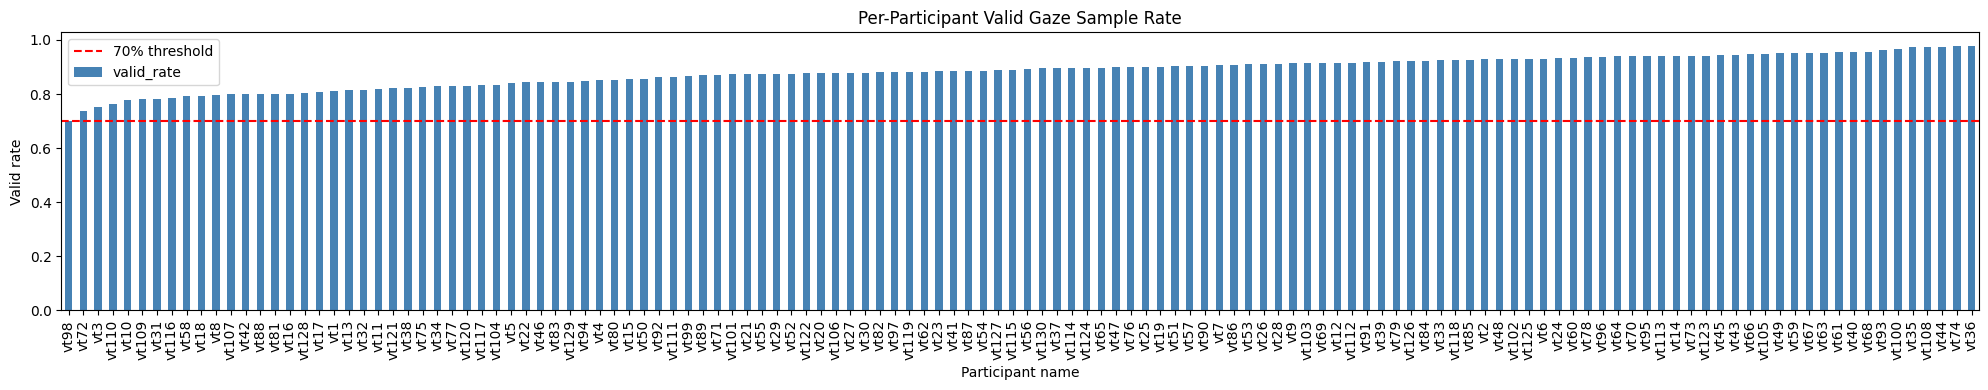

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 4))
quality['valid_rate'].sort_values().plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.70, color='red', linestyle='--', label='70% threshold')
ax.set_title('Per-Participant Valid Gaze Sample Rate')
ax.set_ylabel('Valid rate')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/01_gaze_quality.png', dpi=150)
plt.show()

## 6. Participant ID Alignment Check

In [10]:
metrics_participants = set(metrics[MetricsCols.PARTICIPANT].unique())
gaze_participants    = set(gaze[ExportCols.PARTICIPANT_NAME].unique())

only_in_metrics = metrics_participants - gaze_participants
only_in_gaze    = gaze_participants - metrics_participants

print(f"Participants in Metrics only: {only_in_metrics}")
print(f"Participants in Data export only: {only_in_gaze}")
print(f"Shared participants: {len(metrics_participants & gaze_participants)}")

Participants in Metrics only: set()
Participants in Data export only: set()
Shared participants: 130


## 7. Save to Parquet

In [11]:
metrics.drop(columns=['_valid_sample'], errors='ignore').to_parquet(METRICS_CLEAN_PKL, index=False)
gaze.drop(columns=['_valid_sample'], errors='ignore').to_parquet(RAWGAZE_CLEAN_PKL, index=False)

print(f"Saved: {METRICS_CLEAN_PKL}")
print(f"  Shape: {metrics.shape}")
print(f"Saved: {RAWGAZE_CLEAN_PKL}")
print(f"  Shape: {gaze.shape}")

Saved: /home/wlsoo/WID2003/data/processed/metrics_clean.parquet
  Shape: (39000, 53)
Saved: /home/wlsoo/WID2003/data/processed/raw_gaze_clean.parquet
  Shape: (4538514, 155)
